In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#load extracted features
data_efficientnet = np.load("/content/drive/MyDrive/AML/AML_efficientnet_features.npz", allow_pickle=True)
data_resnet   = np.load("/content/drive/MyDrive/AML/AML_resnet_features.npz", allow_pickle=True)
data_mobilenet   = np.load("/content/drive/MyDrive/AML/AML_mobilenet_features.npz", allow_pickle=True)

feature_sets = {
    "mobilenet": data_mobilenet,
    "resnet": data_resnet,
    "efficientnet": data_efficientnet
}

### Label mapping

- `0` = control  
- `1` = NPM1  
- `2` = PML_RARA  
- `3` = RUNX1_RUNX1T1  
- `4` = CBFB_MYH11




In [ ]:
# Iterate through the dictionary to check labels in each file
for model_name, data in feature_sets.items():

    y_labels = data["y_img"]
    unique_labels = np.unique(y_labels)

    print(f"--- {model_name.upper()} ---")
    print(f"Unique labels: {unique_labels}")
    print(f"Total samples: {len(y_labels)}")
    print(f"Label distribution: {np.bincount(y_labels) if y_labels.dtype == int else 'N/A'}")
    print("\n")

--- MOBILENET ---
Unique labels: [0 1 2 3 4]
Total samples: 81220
Label distribution: [20305 17715 11585 14403 17212]


--- RESNET ---
Unique labels: [0 1 2 3 4]
Total samples: 81220
Label distribution: [20305 17715 11585 14403 17212]


--- EFFICIENTNET ---
Unique labels: [0 1 2 3 4]
Total samples: 81220
Label distribution: [20305 17715 11585 14403 17212]




In [ ]:
#patient Aggregate function
def aggregate_patient_features(X, patient_ids, labels):
    df_feat = pd.DataFrame(X)
    df_feat["patient_id"] = patient_ids
    df_feat["target"] = labels

    feature_cols = df_feat.columns[:-2]

    grouped_X = df_feat.groupby("patient_id")[feature_cols].mean()
    grouped_y = df_feat.groupby("patient_id")["target"].first()

    return (
        grouped_X.values,
        grouped_y.values.astype(int),
        grouped_X.index.values
    )

In [ ]:
# Build patient-level data for all backbones
patient_level_data = {}

for model_name, data in feature_sets.items():
    X_patient, y_patient, pids_patient = aggregate_patient_features(
        data["X_img"],
        data["pids_img"],
        data["y_img"]
    )

    patient_level_data[model_name] = {
        "X_patient": X_patient,
        "y_patient": y_patient,
        "pids_patient": pids_patient
    }

    print(f"{model_name}:")
    print("Patient-level feature shape:", X_patient.shape)
    print("Number of patients:", len(pids_patient))
    print("Patient label distribution:", np.bincount(y_patient))
    print()

mobilenet:
Patient-level feature shape: (189, 1280)
Number of patients: 189
Patient label distribution: [60 36 24 32 37]

resnet:
Patient-level feature shape: (189, 2048)
Number of patients: 189
Patient label distribution: [60 36 24 32 37]

efficientnet:
Patient-level feature shape: (189, 1280)
Number of patients: 189
Patient label distribution: [60 36 24 32 37]



In [ ]:
# Validate that all backbones contain the same patient set and matching labels
reference_name = "efficientnet"
ref_pids = patient_level_data[reference_name]["pids_patient"]
ref_labels = patient_level_data[reference_name]["y_patient"]

ref_df = pd.DataFrame({
    "patient_id": ref_pids,
    "target": ref_labels
}).sort_values("patient_id").reset_index(drop=True)

for model_name, pdata in patient_level_data.items():
    cmp_df = pd.DataFrame({
        "patient_id": pdata["pids_patient"],
        "target": pdata["y_patient"]
    }).sort_values("patient_id").reset_index(drop=True)

    same_patients = ref_df["patient_id"].tolist() == cmp_df["patient_id"].tolist()
    same_labels = ref_df["target"].tolist() == cmp_df["target"].tolist()

    print(f"{model_name}: patient set matches reference -> {same_patients}")
    print(f"{model_name}: patient labels match reference -> {same_labels}")
    print()

    assert same_patients, f"Patient mismatch found in {model_name}"
    assert same_labels, f"Label mismatch found in {model_name}"

mobilenet: patient set matches reference -> True
mobilenet: patient labels match reference -> True

resnet: patient set matches reference -> True
resnet: patient labels match reference -> True

efficientnet: patient set matches reference -> True
efficientnet: patient labels match reference -> True



In [ ]:
# Create one common patient-level train/test split using the reference backbone
train_patients, test_patients = train_test_split(
    ref_df,
    test_size=0.2,
    stratify=ref_df["target"],
    random_state=42
)

train_ids = train_patients["patient_id"].values
test_ids = test_patients["patient_id"].values

print("Train patients:", len(train_ids))
print("Test patients:", len(test_ids))
print("Train label distribution:", np.bincount(train_patients["target"]))
print("Test label distribution:", np.bincount(test_patients["target"]))

Train patients: 151
Test patients: 38
Train label distribution: [48 29 19 26 29]
Test label distribution: [12  7  5  6  8]


In [ ]:
# Compare all backbones using the same split and the same XGBoost classifier
results = {}
results_rows = []

for backbone_name, pdata in patient_level_data.items():
    print("=" * 70)
    print(f"Running backbone: {backbone_name}")
    start_time = time.time()

    img_patient_df = pd.DataFrame(pdata["X_patient"])
    img_patient_df["patient_id"] = pdata["pids_patient"]
    img_patient_df["target"] = pdata["y_patient"]

    train_img_patient = img_patient_df.set_index("patient_id").loc[train_ids].reset_index()
    test_img_patient = img_patient_df.set_index("patient_id").loc[test_ids].reset_index()

    y_train = train_img_patient["target"].values.astype(int)
    y_test = test_img_patient["target"].values.astype(int)

    X_train = train_img_patient.drop(columns=["patient_id", "target"]).values
    X_test = test_img_patient.drop(columns=["patient_id", "target"]).values

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA to retain 95% variance
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print("Original feature size:", X_train.shape[1])
    print("PCA feature size:", X_train_pca.shape[1])

    # Handle class imbalance
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    # Same downstream classifier for all backbones
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train)),
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss"
    )

    model.fit(X_train_pca, y_train, sample_weight=sample_weights)
    y_pred = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.6f}")
    print(f"Weighted F1: {weighted_f1:.6f}")
    print(f"Macro F1: {macro_f1:.6f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(cm)
    print(f"Time: {time.time() - start_time:.2f} seconds")

    results[backbone_name] = {
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
        "confusion_matrix": cm,
        "classification_report": classification_report(y_test, y_pred, zero_division=0)
    }

    results_rows.append({
        "Backbone": backbone_name,
        "Accuracy": accuracy,
        "Weighted_F1_Score": weighted_f1,
        "Macro_F1_Score": macro_f1
    })

Running backbone: mobilenet
Original feature size: 1280
PCA feature size: 42
Accuracy: 0.736842
Weighted F1: 0.732241
Macro F1: 0.685993

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.80      0.57      0.67         7
           2       0.50      0.40      0.44         5
           3       0.80      0.67      0.73         6
           4       0.55      0.75      0.63         8

    accuracy                           0.74        38
   macro avg       0.71      0.68      0.69        38
weighted avg       0.75      0.74      0.73        38

Confusion Matrix:
[[12  0  0  0  0]
 [ 1  4  1  0  1]
 [ 0  1  2  0  2]
 [ 0  0  0  4  2]
 [ 0  0  1  1  6]]
Time: 0.95 seconds
Running backbone: resnet
Original feature size: 2048
PCA feature size: 44
Accuracy: 0.763158
Weighted F1: 0.748132
Macro F1: 0.706405

Classification Report:
              precision    recall  f1-score   support

         

In [ ]:
# Final comparison table
results_df = pd.DataFrame(results_rows).sort_values(
    by="Weighted_F1_Score",
    ascending=False
).reset_index(drop=True)

print(results_df)

       Backbone  Accuracy  Weighted_F1_Score  Macro_F1_Score
0        resnet  0.763158           0.748132        0.706405
1     mobilenet  0.736842           0.732241        0.685993
2  efficientnet  0.657895           0.650877        0.596667


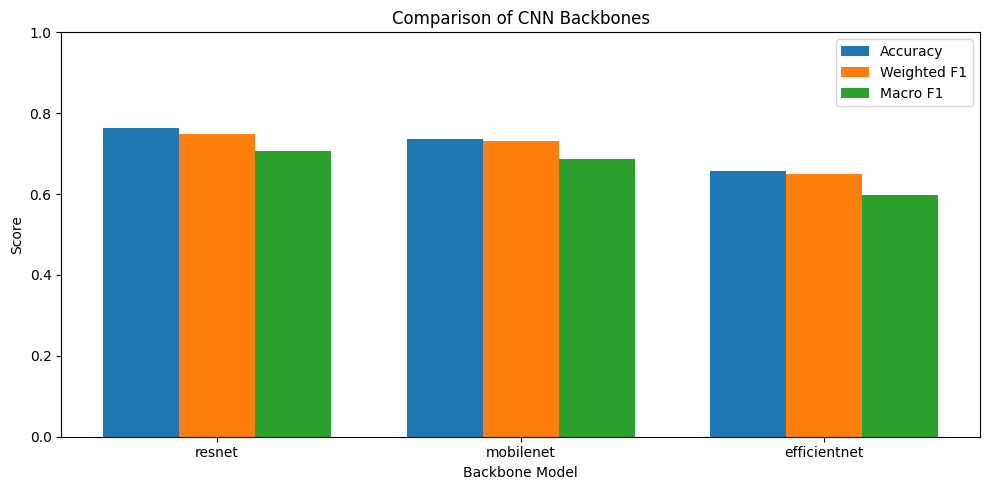

In [ ]:
#plot
plot_df = results_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x, plot_df["Weighted_F1_Score"], width, label="Weighted F1")
plt.bar(x + width, plot_df["Macro_F1_Score"], width, label="Macro F1")

plt.title("Comparison of CNN Backbones")
plt.xlabel("Backbone Model")
plt.ylabel("Score")
plt.xticks(x, plot_df["Backbone"])
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()